# DS605 | LAB06 | Image and Text

## Part A | Image Extraction and Classification

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import time

In [2]:
DATASET_PATH = r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack"

CRACK_PATH = os.path.join(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks")
NON_CRACK_PATH = os.path.join(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\NonCracks")

print("Crack folder:",r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks")
print("Non-crack folder:", r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\NonCracks")

Crack folder: C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks
Non-crack folder: C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\NonCracks


In [3]:
print("Crack folder exists:", os.path.exists(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks"))
print("Non-crack folder exists:", os.path.exists(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\NonCracks"))

Crack folder exists: True
Non-crack folder exists: True


In [4]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

crack_files = [
    f for f in os.listdir(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks")
    if f.lower().endswith(image_extensions)
]

non_crack_files = [
    f for f in os.listdir(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\NonCracks")
    if f.lower().endswith(image_extensions)
]

print("Number of crack images:", len(crack_files))
print("Number of non-crack images:", len(non_crack_files))
print("Total images:", len(crack_files) + len(non_crack_files))

Number of crack images: 200
Number of non-crack images: 200
Total images: 400


In [5]:
sample_path = os.path.join(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks", crack_files[0])

image = cv2.imread(sample_path)

print("Image path:", sample_path)
print("Image shape:", image.shape)
print("Image data type:", image.dtype)

Image path: C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\asphalt_crack\Cracks\IMG_20180513_164959951_HDR resized_448.jpg
Image shape: (448, 448, 3)
Image data type: uint8


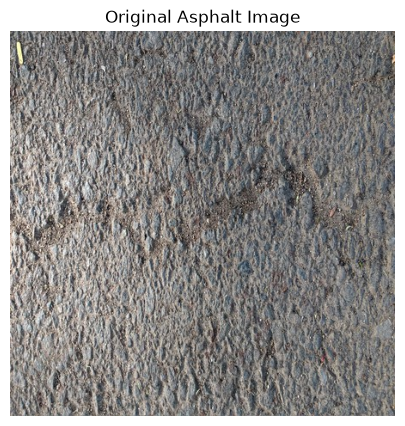

In [6]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.title("Original Asphalt Image")
plt.axis("off")
plt.show()

In [7]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("Original shape:", image.shape)
print("Grayscale shape:", gray.shape)

Original shape: (448, 448, 3)
Grayscale shape: (448, 448)


In [8]:
IMG_SIZE = (224, 224)

gray_resized = cv2.resize(gray, IMG_SIZE)

print("Resized grayscale shape:", gray_resized.shape)

Resized grayscale shape: (224, 224)


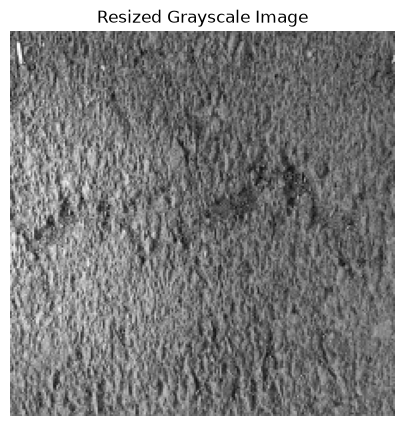

In [9]:
plt.figure(figsize=(8, 5))
plt.imshow(gray_resized, cmap="gray")
plt.title("Resized Grayscale Image")
plt.axis("off")
plt.show()

In [10]:
mean_brightness = np.mean(gray_resized)
contrast = np.std(gray_resized)

dark_threshold = 50
bright_threshold = 200

dark_pixel_ratio = np.mean(gray_resized < dark_threshold)
bright_pixel_ratio = np.mean(gray_resized > bright_threshold)

minimum_intensity = np.min(gray_resized)
maximum_intensity = np.max(gray_resized)

intensity_range = maximum_intensity - minimum_intensity

print("Mean brightness:", mean_brightness)
print("Contrast:", contrast)
print("Dark pixel ratio:", dark_pixel_ratio)
print("Bright pixel ratio:", bright_pixel_ratio)
print("Minimum intensity:", minimum_intensity)
print("Maximum intensity:", maximum_intensity)
print("Intensity range:", intensity_range)

Mean brightness: 122.22161989795919
Contrast: 31.51073548218895
Dark pixel ratio: 0.0038066007653061226
Bright pixel ratio: 0.010941485969387755
Minimum intensity: 23
Maximum intensity: 247
Intensity range: 224


In [11]:
LOW_THRESHOLD = 50
HIGH_THRESHOLD = 150

edges = cv2.Canny(
    gray_resized,
    LOW_THRESHOLD,
    HIGH_THRESHOLD
)

print("Edge image shape:", edges.shape)

Edge image shape: (224, 224)


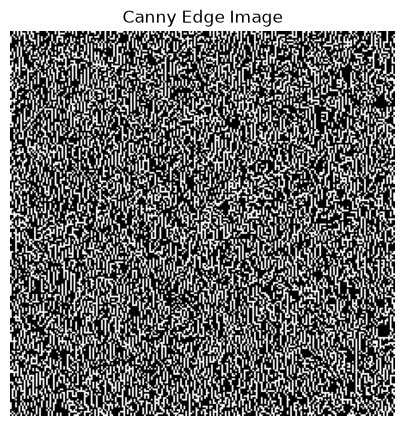

In [12]:
plt.figure(figsize=(8, 5))
plt.imshow(edges, cmap="gray")
plt.title("Canny Edge Image")
plt.axis("off")
plt.show()

In [13]:
edge_pixel_count = np.sum(edges > 0)

total_pixels = edges.size

edge_density = edge_pixel_count / total_pixels

print("Edge pixel count:", edge_pixel_count)
print("Total pixels:", total_pixels)
print("Edge density:", edge_density)

Edge pixel count: 18521
Total pixels: 50176
Edge density: 0.36912069515306123


In [14]:
sample_features = {
    "mean_brightness": mean_brightness,
    "contrast": contrast,
    "dark_pixel_ratio": dark_pixel_ratio,
    "bright_pixel_ratio": bright_pixel_ratio,
    "min_intensity": minimum_intensity,
    "max_intensity": maximum_intensity,
    "intensity_range": intensity_range,
    "edge_count": edge_pixel_count,
    "edge_density": edge_density,
    "label": 1
}

sample_features

{'mean_brightness': np.float64(122.22161989795919),
 'contrast': np.float64(31.51073548218895),
 'dark_pixel_ratio': np.float64(0.0038066007653061226),
 'bright_pixel_ratio': np.float64(0.010941485969387755),
 'min_intensity': np.uint8(23),
 'max_intensity': np.uint8(247),
 'intensity_range': np.uint8(224),
 'edge_count': np.int64(18521),
 'edge_density': np.float64(0.36912069515306123),
 'label': 1}

In [15]:
def extract_image_features(image_path, label):
    
    # Read image
    image = cv2.imread(image_path)
    
    if image is None:
        return None
    
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Resize
    gray = cv2.resize(gray, IMG_SIZE)
    
    # Intensity features
    mean_brightness = np.mean(gray)
    contrast = np.std(gray)
    
    dark_pixel_ratio = np.mean(gray < dark_threshold)
    bright_pixel_ratio = np.mean(gray > bright_threshold)
    
    minimum_intensity = np.min(gray)
    maximum_intensity = np.max(gray)
    intensity_range = maximum_intensity - minimum_intensity
    
    # Canny edges
    edges = cv2.Canny(
        gray,
        LOW_THRESHOLD,
        HIGH_THRESHOLD
    )
    
    # Edge features
    edge_pixel_count = np.sum(edges > 0)
    edge_density = edge_pixel_count / edges.size
    
    return {
        "mean_brightness": mean_brightness,
        "contrast": contrast,
        "dark_pixel_ratio": dark_pixel_ratio,
        "bright_pixel_ratio": bright_pixel_ratio,
        "min_intensity": minimum_intensity,
        "max_intensity": maximum_intensity,
        "intensity_range": intensity_range,
        "edge_count": edge_pixel_count,
        "edge_density": edge_density,
        "label": label
    }

In [16]:
all_features = []

# Crack images
for filename in crack_files:
    
    image_path = os.path.join(CRACK_PATH, filename)
    
    features = extract_image_features(
        image_path,
        label=1
    )
    
    if features is not None:
        all_features.append(features)


# Non-crack images
for filename in non_crack_files:
    
    image_path = os.path.join(NON_CRACK_PATH, filename)
    
    features = extract_image_features(
        image_path,
        label=0
    )
    
    if features is not None:
        all_features.append(features)


print("Total feature rows:", len(all_features))

Total feature rows: 400


In [17]:
features_df = pd.DataFrame(all_features)

print("Shape:", features_df.shape)

features_df.head()

Shape: (400, 10)


,mean_brightness,contrast,dark_pixel_ratio,bright_pixel_ratio,min_intensity,max_intensity,intensity_range,edge_count,edge_density,label
0,122.221620,31.510735,0.003807,0.010941,23,247,224,18521,0.369121,1
1,131.948143,24.094438,0.002790,0.003747,8,251,243,18071,0.360152,1
2,121.296975,29.884574,0.013333,0.008151,2,241,239,17399,0.346759,1
3,130.244340,25.647589,0.001873,0.004026,20,253,233,18706,0.372808,1
4,131.205198,26.238162,0.002352,0.006258,11,253,242,18329,0.365294,1


In [18]:
print(features_df["label"].value_counts())

label
1    200
0    200
Name: count, dtype: int64


In [19]:
features_df.to_csv(
    "image_features.csv",
    index=False
)

print("Saved image_features.csv")

Saved image_features.csv


In [21]:
X = features_df.drop(columns=["label"])
y = features_df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nClass distribution:")
print(y.value_counts())

X shape: (400, 9)
y shape: (400,)

Feature columns:
['mean_brightness', 'contrast', 'dark_pixel_ratio', 'bright_pixel_ratio', 'min_intensity', 'max_intensity', 'intensity_range', 'edge_count', 'edge_density']

Class distribution:
label
1    200
0    200
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 280
Testing samples: 120


In [23]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )
}

In [24]:
results = []

for model_name, model in models.items():
    
    # Training time
    start_train = time.perf_counter()
    model.fit(X_train, y_train)
    end_train = time.perf_counter()
    
    train_time = end_train - start_train
    
    # Prediction time
    start_pred = time.perf_counter()
    y_pred = model.predict(X_test)
    end_pred = time.perf_counter()
    
    prediction_time = end_pred - start_pred
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Train Time (s)": train_time,
        "Prediction Time (s)": prediction_time
    })

results_df = pd.DataFrame(results)

results_df

c:\Users\gpala\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score,Train Time (s),Prediction Time (s)
0,Logistic Regression,0.783333,0.765625,0.816667,0.790323,0.158185,0.001092
1,Decision Tree,0.941667,0.949153,0.933333,0.941176,0.001857,0.000675
2,Random Forest,0.958333,0.966102,0.950000,0.957983,0.094291,0.006127


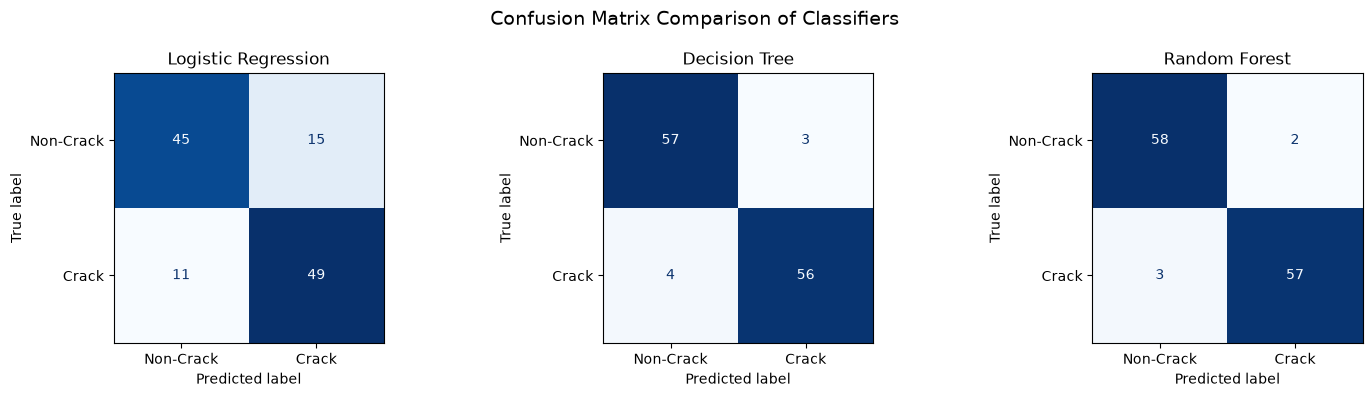

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, model) in zip(axes, models.items()):
    
    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-Crack", "Crack"]
    )
    
    disp.plot(
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    
    ax.set_title(model_name)

plt.suptitle("Confusion Matrix Comparison of Classifiers", fontsize=14)
plt.tight_layout()
plt.show()

## Part B Email Classification

In [29]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [31]:
TEXT_DATASET_PATH = r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\emails.csv"

email_df = pd.read_csv(r"C:\Users\gpala\OneDrive\Desktop\PG\DS605_ML\LAB06_Image_Text\emails.csv")

print("Dataset shape:", email_df.shape)
print("\nColumns:")
print(email_df.columns.tolist())

email_df.head()

Dataset shape: (5172, 3002)

Columns:
['Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will', 'have', 'with', 'your', 'at', 'we', 's', 'are', 'it', 'by', 'com', 'as', 'from', 'gas', 'or', 'not', 'me', 'deal', 'if', 'meter', 'hpl', 'please', 're', 'e', 'any', 'our', 'corp', 'can', 'd', 'all', 'has', 'was', 'know', 'need', 'an', 'forwarded', 'new', 't', 'may', 'up', 'j', 'mmbtu', 'should', 'do', 'am', 'get', 'out', 'see', 'no', 'there', 'price', 'daren', 'but', 'been', 'company', 'l', 'these', 'let', 'so', 'would', 'm', 'into', 'xls', 'farmer', 'attached', 'us', 'information', 'they', 'message', 'day', 'time', 'my', 'one', 'what', 'only', 'http', 'th', 'volume', 'mail', 'contract', 'which', 'month', 'more', 'robert', 'sitara', 'about', 'texas', 'nom', 'energy', 'pec', 'questions', 'www', 'deals', 'volumes', 'pm', 'ena', 'now', 'their', 'file', 'some', 'email', 'just', 'also', 'call', 'change', 'other', 'here',

,Email No.,the,to,ect,and,for,of,a,you,hou,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,Email 1,0,0,1,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Email 2,8,13,24,6,6,2,102,1,27,...,0,0,0,0,0,0,0,1,0,0
2,Email 3,0,0,1,0,0,0,8,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Email 4,0,5,22,0,5,1,51,2,10,...,0,0,0,0,0,0,0,0,0,0
4,Email 5,7,6,17,1,5,2,57,0,9,...,0,0,0,0,0,0,0,1,0,0


In [36]:
print("Dataset shape:", email_df.shape)

print("\nColumns:")
print(email_df.columns.tolist()[:20])

print("\nLast columns:")
print(email_df.columns.tolist()[-10:])

print("\nFirst 5 rows:")
display(email_df.head())

Dataset shape: (5172, 3003)

Columns:
['level_0', 'Email No.', 'the', 'to', 'ect', 'and', 'for', 'of', 'a', 'you', 'hou', 'in', 'on', 'is', 'this', 'enron', 'i', 'be', 'that', 'will']

Last columns:
['connevey', 'jay', 'valued', 'lay', 'infrastructure', 'military', 'allowing', 'ff', 'dry', 'Prediction']

First 5 rows:


,level_0,Email No.,the,to,ect,and,for,of,a,you,...,connevey,jay,valued,lay,infrastructure,military,allowing,ff,dry,Prediction
0,0,Email 1,0,0,1,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,1,Email 2,8,13,24,6,6,2,102,1,...,0,0,0,0,0,0,0,1,0,0
2,2,Email 3,0,0,1,0,0,0,8,0,...,0,0,0,0,0,0,0,0,0,0
3,3,Email 4,0,5,22,0,5,1,51,2,...,0,0,0,0,0,0,0,0,0,0
4,4,Email 5,7,6,17,1,5,2,57,0,...,0,0,0,0,0,0,0,1,0,0


In [37]:
print("\nTarget data type:")
print(email_df["Prediction"].dtype)

print("\nUnique values:")
print(email_df["Prediction"].unique())


Target data type:
int64

Unique values:
[0 1]


In [38]:
X_text = email_df.drop(
    columns=["level_0", "Email No.", "Prediction"]
)

y_text = email_df["Prediction"]

print("Feature matrix shape:", X_text.shape)
print("Target shape:", y_text.shape)

Feature matrix shape: (5172, 3000)
Target shape: (5172,)


In [39]:
X_text_train, X_text_test, y_text_train, y_text_test = train_test_split(
    X_text,
    y_text,
    test_size=0.30,
    random_state=42,
    stratify=y_text
)

print("Training samples:", X_text_train.shape[0])
print("Testing samples:", X_text_test.shape[0])

Training samples: 3620
Testing samples: 1552


In [40]:
text_lr = LogisticRegression(
    max_iter=1000
)

start_train = time.perf_counter()

text_lr.fit(
    X_text_train,
    y_text_train
)

text_train_time = time.perf_counter() - start_train

print("Training completed.")
print("Training time:", text_train_time, "seconds")

Training completed.
Training time: 12.36123410006985 seconds


In [41]:
start_pred = time.perf_counter()

y_text_pred = text_lr.predict(X_text_test)

text_prediction_time = time.perf_counter() - start_pred

print("Prediction completed.")
print("Prediction time:", text_prediction_time, "seconds")

Prediction completed.
Prediction time: 0.11032400000840425 seconds


In [42]:
text_accuracy = accuracy_score(
    y_text_test,
    y_text_pred
)

text_precision = precision_score(
    y_text_test,
    y_text_pred,
    zero_division=0
)

text_recall = recall_score(
    y_text_test,
    y_text_pred,
    zero_division=0
)

text_f1 = f1_score(
    y_text_test,
    y_text_pred,
    zero_division=0
)

print("Text Classification Results")
print("=" * 40)
print("Accuracy :", text_accuracy)
print("Precision:", text_precision)
print("Recall   :", text_recall)
print("F1 Score :", text_f1)
print("Train time:", text_train_time)
print("Prediction time:", text_prediction_time)

Text Classification Results
Accuracy : 0.9800257731958762
Precision: 0.9604395604395605
Recall   : 0.9711111111111111
F1 Score : 0.9657458563535911
Train time: 12.36123410006985
Prediction time: 0.11032400000840425


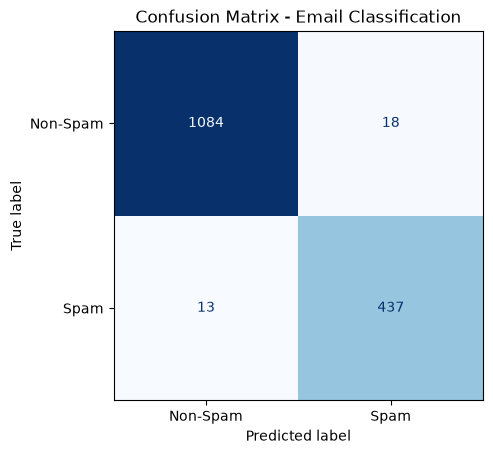

In [43]:
cm_text = confusion_matrix(
    y_text_test,
    y_text_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_text,
    display_labels=["Non-Spam", "Spam"]
)

disp.plot(
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix - Email Classification")
plt.show()

In [44]:
from sklearn.naive_bayes import MultinomialNB

In [45]:
text_nb = MultinomialNB()

start_train = time.perf_counter()

text_nb.fit(
    X_text_train,
    y_text_train
)

nb_train_time = time.perf_counter() - start_train

In [46]:
start_pred = time.perf_counter()

y_nb_pred = text_nb.predict(X_text_test)

nb_prediction_time = time.perf_counter() - start_pred

In [47]:
nb_accuracy = accuracy_score(
    y_text_test,
    y_nb_pred
)

nb_precision = precision_score(
    y_text_test,
    y_nb_pred,
    zero_division=0
)

nb_recall = recall_score(
    y_text_test,
    y_nb_pred,
    zero_division=0
)

nb_f1 = f1_score(
    y_text_test,
    y_nb_pred,
    zero_division=0
)

print("Naive Bayes Results")
print("=" * 40)
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)
print("Train time:", nb_train_time)
print("Prediction time:", nb_prediction_time)

Naive Bayes Results
Accuracy : 0.9426546391752577
Precision: 0.8706365503080082
Recall   : 0.9422222222222222
F1 Score : 0.9050160085378869
Train time: 0.143034000066109
Prediction time: 0.11123329994734377


In [48]:
text_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Features": X_text_train.shape[1],
        "Accuracy": text_accuracy,
        "Precision": text_precision,
        "Recall": text_recall,
        "F1 Score": text_f1,
        "Train Time (s)": text_train_time,
        "Prediction Time (s)": text_prediction_time
    },
    {
        "Model": "Multinomial Naive Bayes",
        "Features": X_text_train.shape[1],
        "Accuracy": nb_accuracy,
        "Precision": nb_precision,
        "Recall": nb_recall,
        "F1 Score": nb_f1,
        "Train Time (s)": nb_train_time,
        "Prediction Time (s)": nb_prediction_time
    }
])

text_results

,Model,Features,Accuracy,Precision,Recall,F1 Score,Train Time (s),Prediction Time (s)
0,Logistic Regression,3000,0.980026,0.960440,0.971111,0.965746,12.361234,0.110324
1,Multinomial Naive Bayes,3000,0.942655,0.870637,0.942222,0.905016,0.143034,0.111233


In [49]:
print("Minimum feature value:", X_text.min().min())
print("Maximum feature value:", X_text.max().max())

Minimum feature value: 0
Maximum feature value: 2327


## Part C Representation

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [66]:
lr_standardized = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

In [67]:
import time

start_time = time.time()

lr_standardized.fit(X_train, y_train)

train_time_standardized = time.time() - start_time

print("Training time:", train_time_standardized, "seconds")

Training time: 0.028706073760986328 seconds


In [68]:
start_time = time.time()

y_pred_standardized = lr_standardized.predict(X_test)

prediction_time_standardized = time.time() - start_time

print("Prediction time:", prediction_time_standardized, "seconds")

Prediction time: 0.00582575798034668 seconds


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_standardized = accuracy_score(
    y_test,
    y_pred_standardized
)

precision_standardized = precision_score(
    y_test,
    y_pred_standardized
)

recall_standardized = recall_score(
    y_test,
    y_pred_standardized
)

f1_standardized = f1_score(
    y_test,
    y_pred_standardized
)

print("Accuracy :", accuracy_standardized)
print("Precision:", precision_standardized)
print("Recall   :", recall_standardized)
print("F1 Score :", f1_standardized)

Accuracy : 0.9416666666666667
Precision: 0.9344262295081968
Recall   : 0.95
F1 Score : 0.9421487603305785


In [70]:
print("===== PART C: STANDARDIZATION + LOGISTIC REGRESSION =====")

print("Accuracy  :", round(accuracy_standardized * 100, 2), "%")
print("Precision :", round(precision_standardized * 100, 2), "%")
print("Recall    :", round(recall_standardized * 100, 2), "%")
print("F1 Score  :", round(f1_standardized * 100, 2), "%")

print("\nComputation:")
print("Training time   :", round(train_time_standardized, 4), "seconds")
print("Prediction time :", round(prediction_time_standardized, 4), "seconds")

===== PART C: STANDARDIZATION + LOGISTIC REGRESSION =====
Accuracy  : 94.17 %
Precision : 93.44 %
Recall    : 95.0 %
F1 Score  : 94.21 %

Computation:
Training time   : 0.0287 seconds
Prediction time : 0.0058 seconds


In [71]:
part_c_image_comparison = pd.DataFrame({
    "Representation": [
        "Original Features",
        "Standardized Features"
    ],
    
    "Accuracy (%)": [
        78.33,
        accuracy_standardized * 100
    ],
    
    "Precision (%)": [
        76.56,
        precision_standardized * 100
    ],
    
    "Recall (%)": [
        81.67,
        recall_standardized * 100
    ],
    
    "F1 Score (%)": [
        79.03,
        f1_standardized * 100
    ],
    
    "Training Time (s)": [
        None,
        train_time_standardized
    ],
    
    "Prediction Time (s)": [
        None,
        prediction_time_standardized
    ]
})

part_c_image_comparison

,Representation,Accuracy (%),Precision (%),Recall (%),F1 Score (%),Training Time (s),Prediction Time (s)
0,Original Features,78.330000,76.560000,81.67,79.030000,NaN,NaN
1,Standardized Features,94.166667,93.442623,95.00,94.214876,0.028706,0.005826
